# Exploratory data analysis on OpenNeuro data

### Atif M. Mahmud

### Introduction

This data has been downloaded from https://openneuro.org/datasets/ds003838/versions/1.0.6

This excerpt is from the webpage:
> 
> This dataset consists of raw 64-channel EEG, cardiovascular (electrocardiography and photoplethysmography), and pupillometry data from 86 human participants during 4 minutes of eyes-closed resting and during performance of a
> classic working memory task – digit span task with serial recall. The participants either memorized (memory) or just listened to (control condition) sequences of 5, 9, or 13 digits presented auditorily with 2 second stimulus
> onset asynchrony. The dataset can be used for (1) developing algorithms for cognitive load discrimination and detection of cognitive overload; (2) studying neural (event-related potentials and brain oscillations) and
> peripheral physiological (electrocardiography, photoplethysmography, and pupillometry) signals during encoding and maintenance of each sequentially presented memory item in a fine time scale; (3) correlating cognitive load and > individual differences in working memory to neural and peripheral physiology, and studying the relationship between the physiological signals; (4) integration of the physiological findings with the vast knowledge coming from
> behavioral studies of verbal working memory in simple span paradigms.
> 
> EEG, pupillometry, ECG and photoplethysmography, and behavioral data are stored separately in corresponding folders. Each data record can consist of four data folders:  
> - beh - behavioral data: correctness of the recall in the memory trials
> - ecg - electrocardiography (ECG)
> - photoplethysmography (PPG) data
> - eeg - EEG data
> - pupil - pupillometry and eye-tracking data
> 
> Some of the participants had some physiological data missing: sub-017, sub-094 have no pupillometry data sub-017, sub-037, sub-066 have no ECG and PPG data sub-013, sub-014, sub-015, sub-016, sub-017, sub-018, sub-019,
> sub-020, sub-021, sub-022, sub-023, sub-024, sub-025, sub-026, sub-027, sub-028, sub-029, sub-030, sub-031, sub-037, sub-066 have no EEG data

## Our analysis

There are 86 participants. For simplicity we will start EDA on a subset of the participants - 20 participants. We won't use the following because they have missing data.  
- sub-013 to sub-031
- sub-037
- sub-066
- sub-094

### We will use participants 40-59 for our analysis

### We will start by exploring the individual data of participant 40

c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\atifm\AppData\Local\Temp\ipykernel_73972\856822084.py:4: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_sub40_task = mne.io.read_raw_eeglab("data/sub-040/eeg/sub-040_task-memory_eeg.set", preload=True)


The shape of the date is (63, 7176340)


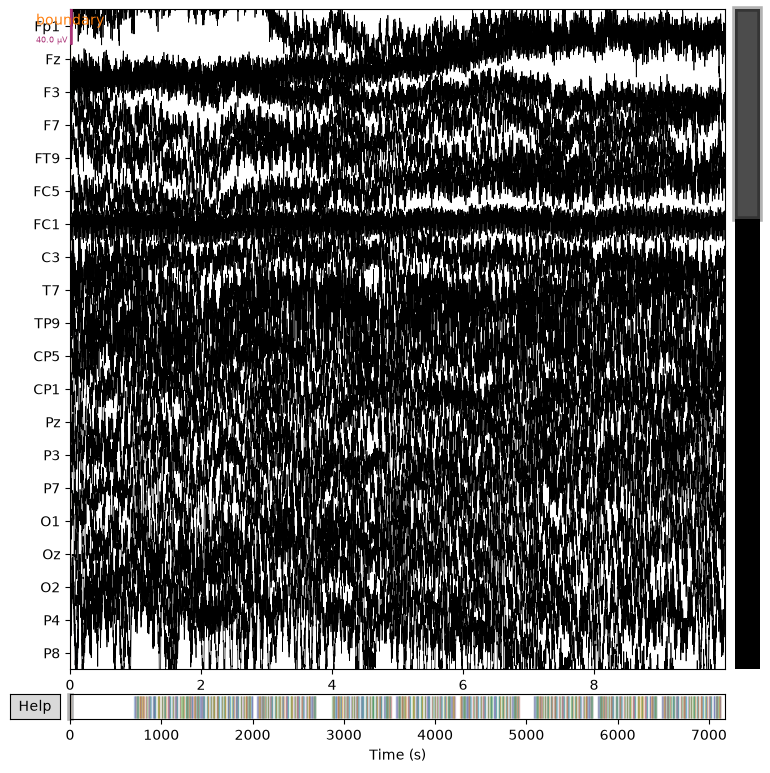

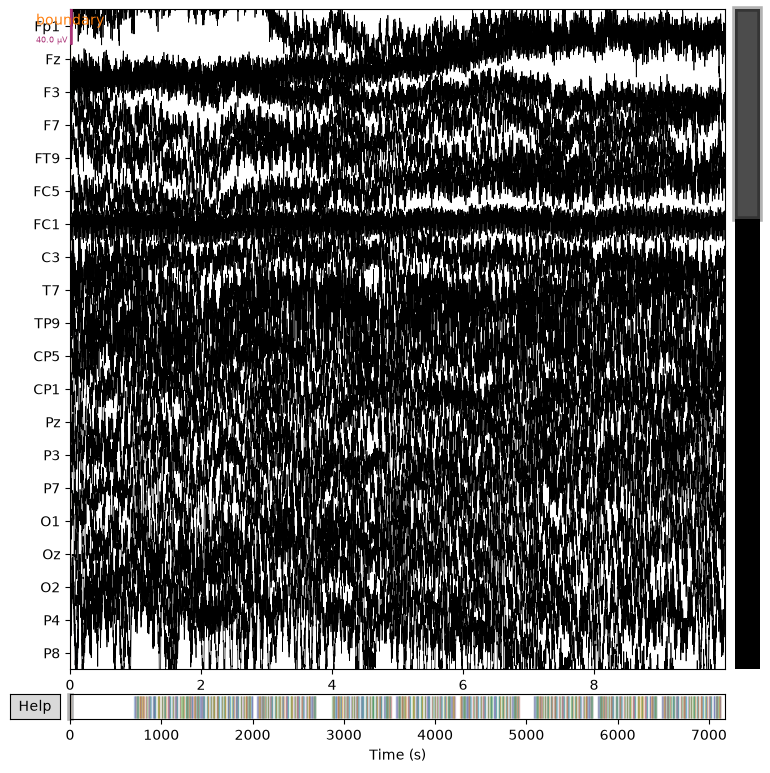

In [ ]:
import mne
import pandas

# The EEG data is in the `_eeg.set` files
raw_sub40_task = mne.io.read_raw_eeglab("data/sub-040/eeg/sub-040_task-memory_eeg.set", preload=True)
print(f"The shape of the date is {raw_sub40_task.get_data().shape}")
raw_sub40_task.plot()

From participant 40, we see that we are able to load the EEG data using `mne` and `pymatreader`. This is a 64-channel EEG, so we have 63-channels of data since one of the channels is a reference and the other values are recorded in reference to that.

## Now we will explore EEG data for each participant

In [ ]:
participants = range(40, 60)

# raw_sub40_task = mne.io.read_raw_eeglab("data/sub-040/eeg/sub-040_task-memory_eeg.set", preload=True)
# print(f"The shape of the date is {raw_sub40_task.get_data().shape}")
# raw_sub40_task.plot()

rows = []
for num in participants:
    file = f"data/sub-0{num}/eeg/sub-0{num}_task-memory_eeg.set"
    raw = mne.io.read_raw_eeglab(file)
    rows.append({"participant" : f"{num}", "rows" : f"{raw.get_data().shape[0]}", "columns" : f"{raw.get_data().shape[1]}"})

df_eeg = pd.DataFrame(rows)
display(df_eeg)

c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Reading d:\GradSchool\SFU\Courses\IAT-882\Final Project\cognitive-load-biomarkers\data\sub-040\eeg\sub-040_task-memory_eeg.set


c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\atifm\AppData\Local\Temp\ipykernel_73972\2921732595.py:9: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file)
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Participant 40. The EEG shape is 63 rows 7176340 columns
Reading d:\GradSchool\SFU\Courses\IAT-882\Final Project\cognitive-load-biomarkers\data\sub-041\eeg\sub-041_task-memory_eeg.set


c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\atifm\AppData\Local\Temp\ipykernel_73972\2921732595.py:9: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file)
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


...

Participant 57. The EEG shape is 63 rows 7443940 columns
Reading d:\GradSchool\SFU\Courses\IAT-882\Final Project\cognitive-load-biomarkers\data\sub-058\eeg\sub-058_task-memory_eeg.set


c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\atifm\AppData\Local\Temp\ipykernel_73972\2921732595.py:9: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file)
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Participant 58. The EEG shape is 63 rows 7561940 columns
Reading d:\GradSchool\SFU\Courses\IAT-882\Final Project\cognitive-load-biomarkers\data\sub-059\eeg\sub-059_task-memory_eeg.set


c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\atifm\AppData\Local\Temp\ipykernel_73972\2921732595.py:9: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file)
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\pymatreader\utils.py:225: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Participant 59. The EEG shape is 63 rows 8106780 columns
